# Late Fusion: улыбка + брови + нахмуривание
**Цель:** сравнить два способа объединения предсказаний трёх моделей:
1. **Average Fusion** — простое среднее вероятностей
2. **Stacking** — мета-модель (LogReg) на трёх вероятностях

CV: StratifiedGroupKFold(5) по Patient. Оценка на уровне пациентов (mean по ретейкам).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                              f1_score, precision_score, recall_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SCORING = ['roc_auc', 'balanced_accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']

def all_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'AUC':       roc_auc_score(y_true, y_prob),
        'BAcc':      balanced_accuracy_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
    }

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold
    def fit(self, X, y=None):
        X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        corr = X_df.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        cols = list(upper.columns)
        to_drop = set(c for c in cols if any(upper[c] > self.threshold))
        self.keep_mask_ = np.array([c not in to_drop for c in cols])
        return self
    def transform(self, X, y=None):
        arr = X.values if isinstance(X, pd.DataFrame) else np.array(X)
        return arr[:, self.keep_mask_]

print('Импорты OK')

Импорты OK


## 1. Загрузка данных

In [4]:
SMILE_PATH = '../iteration 5 (smile)/data_ML_smile_pivot_dinamika_areas.csv'
BROW_PATH  = '../iteration 6 (brow)/data_ML_brow_pivot_dinamika_areas.csv'
FROWN_PATH = '../iteration 7 (frown)/data_ML_frown_pivot_dinamika_areas.csv'

smile_df = pd.read_csv(SMILE_PATH)
brow_df  = pd.read_csv(BROW_PATH)
frown_df = pd.read_csv(FROWN_PATH)

for df_ in [smile_df, brow_df, frown_df]:
    for col in [c for c in df_.columns if c.startswith('dist_') or c.startswith('area_')]:
        df_[col] = pd.to_numeric(df_[col], errors='coerce')

# Геом+Дин без ex_dur — для улыбки и бровей
# Только Динамика  — для нахмуривания (геометрия там не помогает без ex_dur)
AGG_GEOM = ['min_norm', 'max_norm', 'mean_norm', 'median_norm', 'std_norm']
AGG_VEL  = ['max_vel_norm', 'mean_vel_norm', 'std_vel_norm']
AGG_ACC  = ['max_acc_norm', 'std_acc_norm']
AGG_DYN  = AGG_VEL + AGG_ACC

def get_feats(df, agg_groups):
    return [c for c in df.columns
            if c.startswith('dist_') and any(c.endswith(f'_{a}') for a in agg_groups)]

SMILE_FEATS = get_feats(smile_df, AGG_GEOM + AGG_DYN)   # Геом+Дин
BROW_FEATS  = get_feats(brow_df,  AGG_GEOM + AGG_DYN)   # Геом+Дин
FROWN_FEATS = get_feats(frown_df, AGG_DYN)               # Только Динамика

print(f'Улыбка:       {smile_df.shape}, признаков={len(SMILE_FEATS)} (Геом+Дин)')
print(f'Брови:        {brow_df.shape},  признаков={len(BROW_FEATS)} (Геом+Дин)')
print(f'Нахмуривание: {frown_df.shape},  признаков={len(FROWN_FEATS)} (Динамика)')

Улыбка:       (255, 1219), признаков=620 (Геом+Дин)
Брови:        (257, 1307),  признаков=240 (Геом+Дин)
Нахмуривание: (256, 2184),  признаков=125 (Динамика)


## 2. Фильтрация: 150 общих пациентов

In [6]:
common_patients = (
    set(smile_df['id'].unique()) &
    set(brow_df['id'].unique()) &
    set(frown_df['id'].unique())
)
print(f'Пациентов во всех трёх упражнениях: {len(common_patients)}')

smile_df = smile_df[smile_df['id'].isin(common_patients)].reset_index(drop=True)
brow_df  = brow_df[brow_df['id'].isin(common_patients)].reset_index(drop=True)
frown_df = frown_df[frown_df['id'].isin(common_patients)].reset_index(drop=True)

# Пациент-уровневый датафрейм для CV splits
pat_df = (smile_df[['id','label']]
          .drop_duplicates('id')
          .sort_values('id')
          .reset_index(drop=True))
print(f'PD: {(pat_df.label==1).sum()}, Healthy: {(pat_df.label==0).sum()}')

Пациентов во всех трёх упражнениях: 150
PD: 123, Healthy: 27


## 3. Модели

In [8]:
def build_models(y):
    neg, pos = (y==0).sum(), (y==1).sum()
    w = neg / pos
    return {
        'LR':   LogisticRegression(max_iter=2000, class_weight='balanced',
                                   random_state=RANDOM_STATE),
        'RF':   RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                       random_state=RANDOM_STATE),
        'XGB':  XGBClassifier(n_estimators=300, scale_pos_weight=w,
                              eval_metric='logloss', random_state=RANDOM_STATE,
                              verbosity=0),
        'LGBM': LGBMClassifier(n_estimators=300, class_weight='balanced',
                                random_state=RANDOM_STATE, verbose=-1),
        'SVM':  SVC(probability=True, class_weight='balanced',
                    random_state=RANDOM_STATE),
    }

## 4. Функция OOF-предсказаний

In [10]:
def get_oof_probs(df, feat_cols, pat_df, folds):
    """
    Возвращает dict: model_name -> Series(patient -> oof_prob)
    Предсказания агрегируются до уровня пациента (mean по ретейкам).
    folds: list of (train_patient_indices, test_patient_indices) в pat_df
    """
    models = build_models(df['label'])
    oof = {name: {} for name in models}

    for fold_i, (train_idx, test_idx) in enumerate(folds):
        train_pats = set(pat_df.iloc[train_idx]['id'])
        test_pats  = set(pat_df.iloc[test_idx]['id'])

        train_mask = df['id'].isin(train_pats)
        test_mask  = df['id'].isin(test_pats)

        X_train = df.loc[train_mask, feat_cols].values
        y_train = df.loc[train_mask, 'label'].values
        X_test  = df.loc[test_mask, feat_cols].values
        test_ids = df.loc[test_mask, 'id'].values

        for name, model in models.items():
            pipe = Pipeline([
                ('corr',   CorrelationFilter(0.95)),
                ('scaler', StandardScaler()),
                ('model',  model),
            ])
            pipe.fit(X_train, y_train)
            probs = pipe.predict_proba(X_test)[:, 1]

            tmp = pd.DataFrame({'id': test_ids, 'prob': probs})
            pat_probs = tmp.groupby('id')['prob'].mean()
            oof[name].update(pat_probs.to_dict())

    return {name: pd.Series(v) for name, v in oof.items()}

## 5. Единые CV-фолды по 150 пациентам

In [12]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
folds = list(cv.split(pat_df, pat_df['label'], groups=pat_df['id']))
print(f'Фолдов: {len(folds)}')
for i, (tr, te) in enumerate(folds):
    print(f'  Fold {i+1}: train={len(tr)} пац., test={len(te)} пац.')

Фолдов: 5
  Fold 1: train=120 пац., test=30 пац.
  Fold 2: train=120 пац., test=30 пац.
  Fold 3: train=120 пац., test=30 пац.
  Fold 4: train=120 пац., test=30 пац.
  Fold 5: train=120 пац., test=30 пац.


## 6. OOF-предсказания по каждому упражнению

In [14]:
print('Улыбка...')
smile_oof = get_oof_probs(smile_df, SMILE_FEATS, pat_df, folds)
print('Брови...')
brow_oof  = get_oof_probs(brow_df,  BROW_FEATS,  pat_df, folds)
print('Нахмуривание...')
frown_oof = get_oof_probs(frown_df, FROWN_FEATS, pat_df, folds)
print('Готово.')

Улыбка...
Брови...
Нахмуривание...
Готово.


## 7. Метрики каждого упражнения по отдельности

In [16]:
y_pat = pat_df.set_index('id')['label']
model_names = list(smile_oof.keys())
metric_names = ['AUC', 'BAcc', 'F1', 'Precision', 'Recall']

for ex_label, oof_dict in [('Улыбка', smile_oof), ('Брови', brow_oof), ('Нахмуривание', frown_oof)]:
    rows = []
    for name in model_names:
        m = all_metrics(y_pat, oof_dict[name].loc[y_pat.index])
        rows.append({'Модель': name, **m})
    df_ex = pd.DataFrame(rows).set_index('Модель')
    print(f'--- {ex_label} ---')
    print(df_ex.round(3).to_string())
    best = df_ex['AUC'].idxmax()
    print(f'Лучший: {best}  AUC={df_ex.loc[best,"AUC"]:.3f}  BAcc={df_ex.loc[best,"BAcc"]:.3f}')
    print()

--- Улыбка ---
          AUC   BAcc     F1  Precision  Recall
Модель                                        
LR      0.856  0.766  0.820      0.846   0.807
RF      0.792  0.706  0.827      0.827   0.827
XGB     0.824  0.760  0.829      0.845   0.820
LGBM    0.821  0.717  0.824      0.828   0.820
SVM     0.760  0.680  0.808      0.809   0.807
Лучший: LR  AUC=0.856  BAcc=0.766

--- Брови ---
          AUC   BAcc     F1  Precision  Recall
Модель                                        
LR      0.890  0.812  0.845      0.870   0.833
RF      0.826  0.659  0.782      0.793   0.773
XGB     0.874  0.752  0.819      0.839   0.807
LGBM    0.889  0.797  0.844      0.863   0.833
SVM     0.858  0.727  0.820      0.830   0.813
Лучший: LR  AUC=0.890  BAcc=0.812

--- Нахмуривание ---
          AUC   BAcc     F1  Precision  Recall
Модель                                        
LR      0.810  0.687  0.767      0.803   0.747
RF      0.789  0.657  0.795      0.796   0.793
XGB     0.796  0.645  0.779      0

## 8. Average Fusion
Простое среднее вероятностей трёх моделей.

In [18]:
avg_rows = []
for name in model_names:
    avg_prob = (smile_oof[name].loc[y_pat.index] + brow_oof[name].loc[y_pat.index] + frown_oof[name].loc[y_pat.index]) / 3
    m = all_metrics(y_pat, avg_prob)
    avg_rows.append({'Модель': name, **m})

avg_df = pd.DataFrame(avg_rows).set_index('Модель').sort_values('AUC', ascending=False)
print(avg_df.round(3).to_string())

best_avg_model = avg_df.index[0]
best_avg_auc   = avg_df.loc[best_avg_model, 'AUC']
print(f'\nЛучший Average Fusion: {best_avg_model}  AUC={best_avg_auc:.3f}  BAcc={avg_df.loc[best_avg_model,"BAcc"]:.3f}')

          AUC   BAcc     F1  Precision  Recall
Модель                                        
LR      0.924  0.864  0.920      0.920   0.920
LGBM    0.924  0.778  0.872      0.872   0.873
XGB     0.907  0.785  0.863      0.866   0.860
SVM     0.872  0.733  0.846      0.844   0.847
RF      0.859  0.723  0.849      0.846   0.853

Лучший Average Fusion: LR  AUC=0.924  BAcc=0.864


## 9. Stacking Fusion
Мета-модель (LogisticRegression) обучается на трёх OOF-вероятностях.
Оценка: StratifiedKFold(5) на 150 пациентах (patient-level, 3 признака → нет утечки).

In [20]:
from sklearn.model_selection import StratifiedKFold

stack_rows = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name in model_names:
    X_stack = pd.DataFrame({
        'smile': smile_oof[name],
        'brow':  brow_oof[name],
        'frown': frown_oof[name],
    }).loc[y_pat.index]
    y_stack = y_pat

    meta = LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=RANDOM_STATE)
    cv_res = cross_validate(meta, X_stack, y_stack, cv=skf,
                            scoring=dict(
                                AUC='roc_auc',
                                BAcc='balanced_accuracy',
                                F1='f1_weighted',
                                Precision='precision_weighted',
                                Recall='recall_weighted',
                            ))
    stack_rows.append({
        'Модель': name,
        'AUC':       cv_res['test_AUC'].mean(),
        'AUC σ':     cv_res['test_AUC'].std(),
        'BAcc':      cv_res['test_BAcc'].mean(),
        'F1':        cv_res['test_F1'].mean(),
        'Precision': cv_res['test_Precision'].mean(),
        'Recall':    cv_res['test_Recall'].mean(),
    })

stack_df = pd.DataFrame(stack_rows).set_index('Модель').sort_values('AUC', ascending=False)
print(stack_df.round(3).to_string())

best_stack_model = stack_df.index[0]
best_stack_auc   = stack_df.loc[best_stack_model, 'AUC']
print(f'\nЛучший Stacking: {best_stack_model}  AUC={best_stack_auc:.3f}  BAcc={stack_df.loc[best_stack_model,"BAcc"]:.3f}')

          AUC  AUC σ   BAcc     F1  Precision  Recall
Модель                                               
LR      0.928  0.061  0.838  0.864      0.889   0.853
LGBM    0.922  0.017  0.874  0.871      0.901   0.860
XGB     0.901  0.028  0.830  0.837      0.882   0.820
SVM     0.864  0.036  0.805  0.835      0.873   0.820
RF      0.850  0.054  0.810  0.824      0.877   0.807

Лучший Stacking: LR  AUC=0.928  BAcc=0.838


## 10. Веса мета-модели (какому упражнению доверяет больше)

              Коэффициент
Упражнение               
Брови              3.0668
Улыбка             2.0834
Нахмуривание       1.5342


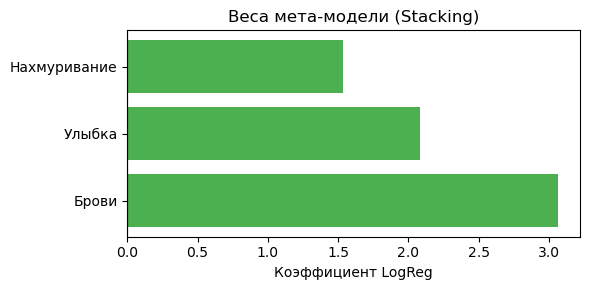

In [22]:
# Обучим мета-модель на всех 150 пациентах (best stacking model)
X_stack_full = pd.DataFrame({
    'smile': smile_oof[best_stack_model],
    'brow':  brow_oof[best_stack_model],
    'frown': frown_oof[best_stack_model],
}).loc[y_pat.index]

meta_full = LogisticRegression(max_iter=1000, class_weight='balanced',
                                random_state=RANDOM_STATE)
meta_full.fit(X_stack_full, y_pat)

coef_df = pd.DataFrame({
    'Упражнение': ['Улыбка', 'Брови', 'Нахмуривание'],
    'Коэффициент': meta_full.coef_[0]
}).set_index('Упражнение').sort_values('Коэффициент', ascending=False)

print(coef_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(6, 3))
colors = ['#4CAF50' if v > 0 else '#F44336' for v in coef_df['Коэффициент']]
ax.barh(coef_df.index, coef_df['Коэффициент'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Веса мета-модели (Stacking)')
ax.set_xlabel('Коэффициент LogReg')
plt.tight_layout()
plt.show()

## 11. Итоговое сравнение всех подходов

                Подход Модель      AUC     BAcc       F1  Precision   Recall
Stacking (LogReg meta)     LR 0.927967 0.837667 0.864026   0.888916 0.853333
        Average Fusion     LR 0.924420 0.864499 0.920000   0.920000 0.920000
          Брови (одна)     LR 0.889792 0.811653 0.844853   0.869773 0.833333
         Улыбка (одна)     LR 0.856369 0.766486 0.820029   0.845864 0.806667
        Нахмур. (одна)   LGBM 0.835893 0.704607 0.807500   0.817716 0.800000


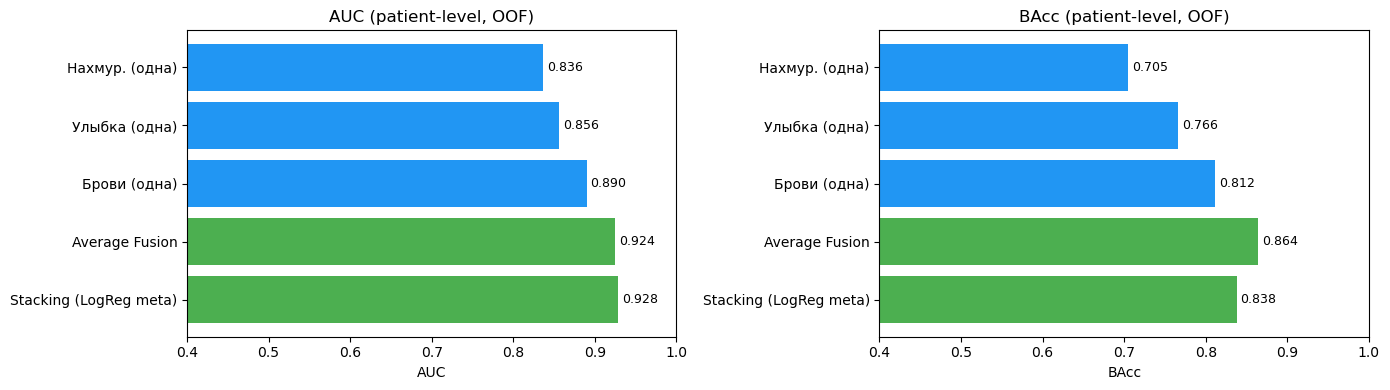

In [24]:
summary_rows = []

# Лучшие одиночные модели
for ex_name, oof_dict in [('Улыбка (одна)', smile_oof),
                           ('Брови (одна)',  brow_oof),
                           ('Нахмур. (одна)', frown_oof)]:
    best_m = max(oof_dict, key=lambda m: roc_auc_score(y_pat, oof_dict[m].loc[y_pat.index]))
    m = all_metrics(y_pat, oof_dict[best_m].loc[y_pat.index])
    summary_rows.append({'Подход': ex_name, 'Модель': best_m, **m})

# Average Fusion
m_avg = avg_df.loc[best_avg_model].to_dict()
summary_rows.append({'Подход': 'Average Fusion', 'Модель': best_avg_model,
                     'AUC': m_avg['AUC'], 'BAcc': m_avg['BAcc'],
                     'F1': m_avg['F1'], 'Precision': m_avg['Precision'], 'Recall': m_avg['Recall']})

# Stacking
m_st = stack_df.loc[best_stack_model]
summary_rows.append({'Подход': 'Stacking (LogReg meta)', 'Модель': best_stack_model,
                     'AUC': m_st['AUC'], 'BAcc': m_st['BAcc'],
                     'F1': m_st['F1'], 'Precision': m_st['Precision'], 'Recall': m_st['Recall']})

summary_df = pd.DataFrame(summary_rows).sort_values('AUC', ascending=False)
print(summary_df.to_string(index=False))

# График по всем метрикам
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors_bar = ['#4CAF50','#4CAF50','#2196F3','#2196F3','#2196F3'][:len(summary_df)]

for ax, metric in zip(axes, ['AUC', 'BAcc']):
    vals = summary_df[metric].values
    bars = ax.barh(summary_df['Подход'], vals, color=colors_bar)
    ax.set_xlim(0.4, 1.0)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} (patient-level, OOF)')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=13)

plt.tight_layout()
plt.show()

## Выводы

- **Average Fusion** улучшает AUC относительно лучшего одиночного упражнения, если упражнения несут независимую информацию о PD.
- **Stacking** дополнительно учитывает, что одни упражнения надёжнее других (через коэффициенты мета-модели).
- Коэффициенты мета-модели показывают относительный вклад каждого упражнения в финальное предсказание.